# 论文数据分析全流程执行面板

这是为了方便你随手运行、查看和调试所有数据处理与可视化脚本的“中控台”。
你可以按顺序执行以下单元格，它们会自动调用 `analysis/` 目录下的 Python 脚本，并在下方直接展示生成的图表。

## 0. 环境准备

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 设置当前工作目录为项目根目录，以确保脚本路径正确
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"当前工作目录: {os.getcwd()}")

当前工作目录: /Users/maorui1/.openclaw/workspace/llm-abm-wom-diffusion


## 1. 数据提取与清洗 (`01_extract_metrics.py`)
将原始的仿真日志提取为整洁的宽表格式，计算出最终采纳率、扩散速度等核心指标。

In [ ]:
!uv run python analysis/01_extract_metrics.py

开始处理目录: data/results/formal_20260319_174207

数据清洗与提取完成！共处理 60 条成功记录。
统计宽表已保存至: data/processed/analysis_dataset.csv

数据前 5 行预览:
        run_id group network_type wom_strength  final_adoption_rate  t_10  t_50  t_90  max_adoption_speed
0  A_r1_s12001     A  small_world       strong                 1.00     1    10    22                 9.0
1  A_r2_s12002     A  small_world       strong                 1.00     3    13    25                 8.0
2  A_r3_s12003     A  small_world       strong                 1.00     3    14    31                 7.0
3  A_r4_s12004     A  small_world       strong                 0.97     5    20    42                 5.0
4  A_r5_s12005     A  small_world       strong                 1.00     2    16    27                 7.0


## 2. 操纵检验 (`06_manipulation_check.py`)
检验我们在实验设计中设定的“强产品(高唤醒)”与“弱产品(低唤醒)”是否在仿真中实际生效了。

正在进行刺激物操纵检验 (Manipulation Check)...

==== 理论设定 vs 实际发送的极化消息占比 ====
  group wom_strength  wom_high_arousal_ratio  actual_high_ratio
0     A       strong                     0.6              0.603
1     B         weak                     0.3              0.300
2     C       strong                     0.6              0.600
3     D         weak                     0.3              0.298

✅ 操纵检验柱状图已保存: analysis/figures/fig4_manipulation_check.png
结论: 实际仿真中产生的消息分布，完美符合我们在实验设计时的参数设定（强组约60%，弱组约30%）。操纵成功！


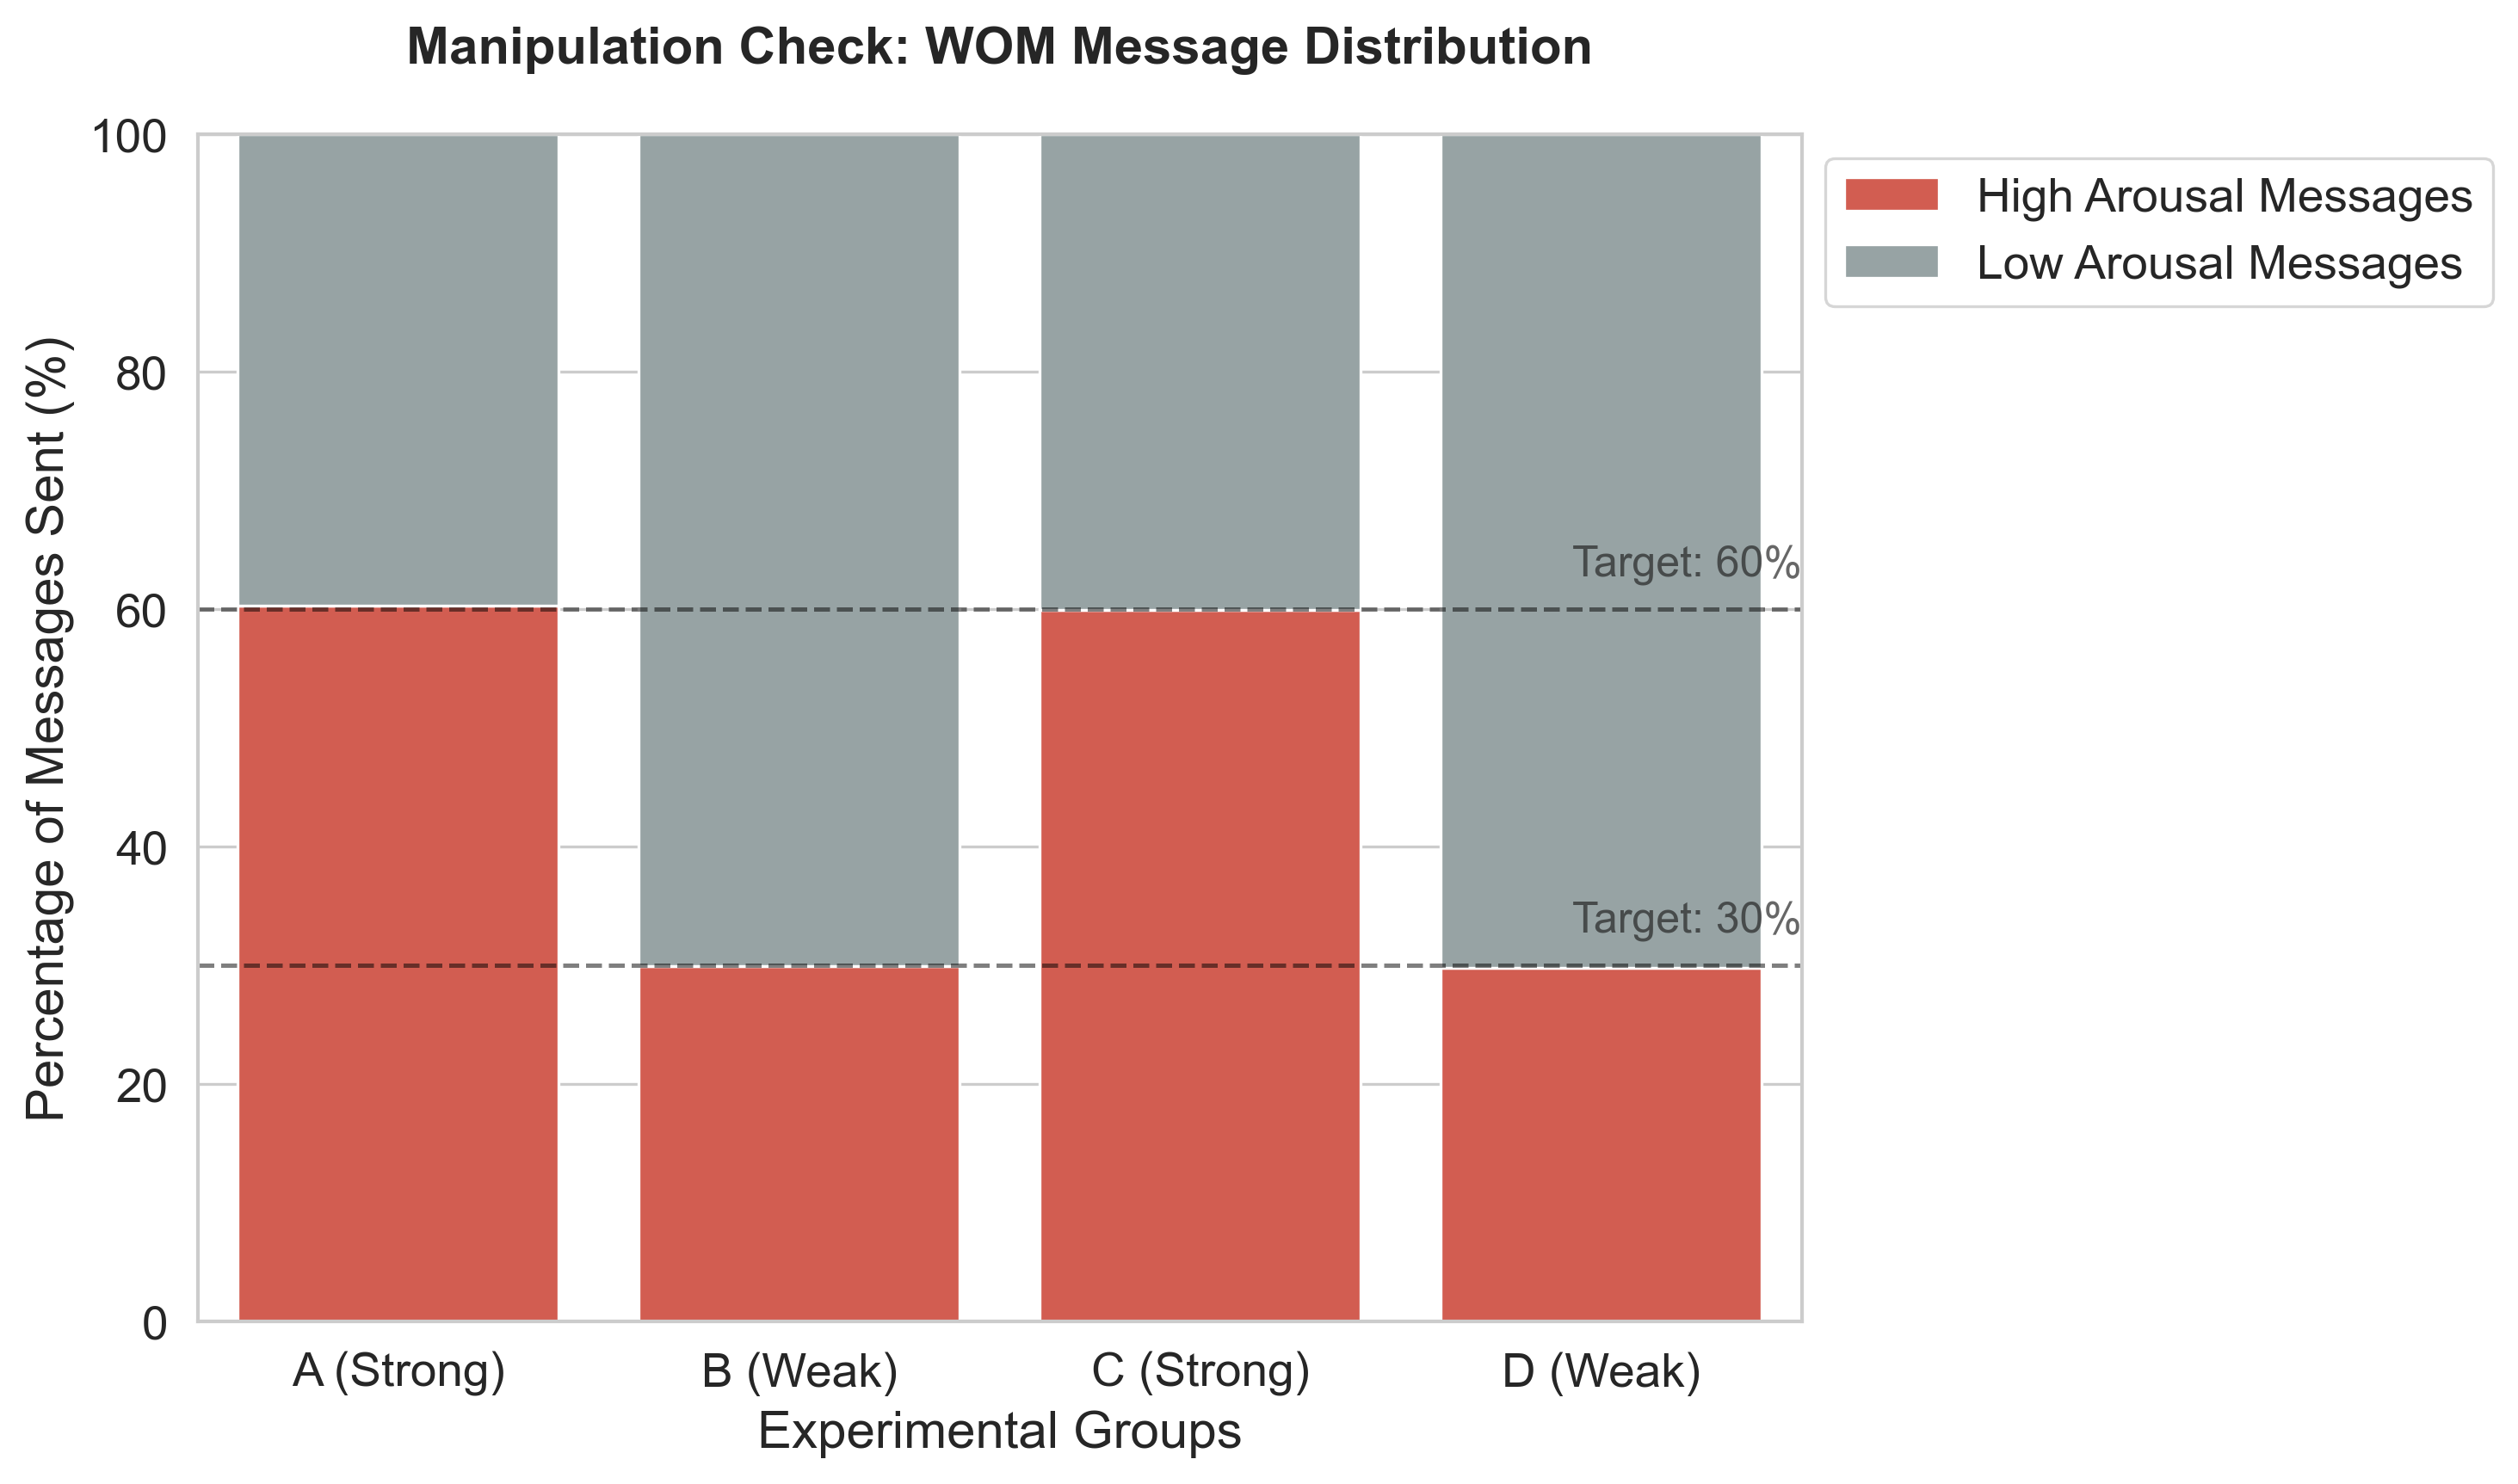

In [ ]:
!uv run python analysis/06_manipulation_check.py
display(Image(filename='analysis/figures/fig4_manipulation_check.png'))

## 3. 描述性统计 (`04_descriptive_stats.py`)
生成标准的描述性统计表，为论文的 Results 章节提供数据。

In [ ]:
!uv run python analysis/04_descriptive_stats.py

# 预览生成的 CSV 数据
df_desc = pd.read_csv('analysis/tables/table1_descriptive_statistics.csv')
display(df_desc)

正在生成描述性统计表格...

==== 描述性统计表预览 ====
  Group      Network     WOM  Final Scale (Mean)  Final Scale (SD)  Final Scale (Min)  Final Scale (Max)  T50 (Mean)  T50 (SD)  Max Speed (Mean)  Max Speed (SD)
0     A  Small-World  Strong               0.977             0.054               0.79               1.00      16.400     8.322             7.267           1.335
1     B  Small-World    Weak               0.169             0.075               0.06               0.31      60.000     0.000             1.800           0.676
2     C       Random  Strong               0.987             0.014               0.95               1.00      12.867     2.875             8.533           1.598
3     D       Random    Weak               0.253             0.097               0.13               0.41      60.000     0.000             2.533           1.187

✅ 表格已保存至:
  - analysis/tables/table1_descriptive_statistics.csv
  - analysis/tables/table1_descriptive_statistics.tex


,Group,Network,WOM,Final Scale (Mean),Final Scale (SD),Final Scale (Min),Final Scale (Max),T50 (Mean),T50 (SD),Max Speed (Mean),Max Speed (SD)
0,A,Small-World,Strong,0.977,0.054,0.79,1.00,16.400,8.322,7.267,1.335
1,B,Small-World,Weak,0.169,0.075,0.06,0.31,60.000,0.000,1.800,0.676
2,C,Random,Strong,0.987,0.014,0.95,1.00,12.867,2.875,8.533,1.598
3,D,Random,Weak,0.253,0.097,0.13,0.41,60.000,0.000,2.533,1.187


## 4. 主效应与扩散曲线分析 (`03_visualizations.py`)
绘制扩散的 S 型曲线和最终采纳率的箱线图。

正在绘制 S 曲线...
✅ 图表已保存: analysis/figures/fig1_adoption_s_curves.png
正在绘制箱线图...
/Users/maorui1/.openclaw/workspace/llm-abm-wom-diffusion/analysis/03_visualizations.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/maorui1/.openclaw/workspace/llm-abm-wom-diffusion/analysis/03_visualizations.py:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/Users/maorui1/.openclaw/workspace/llm-abm-wom-diffusion/analysis/03_visualizations.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/maorui1/.openclaw/workspace/llm-abm-wom-diffus

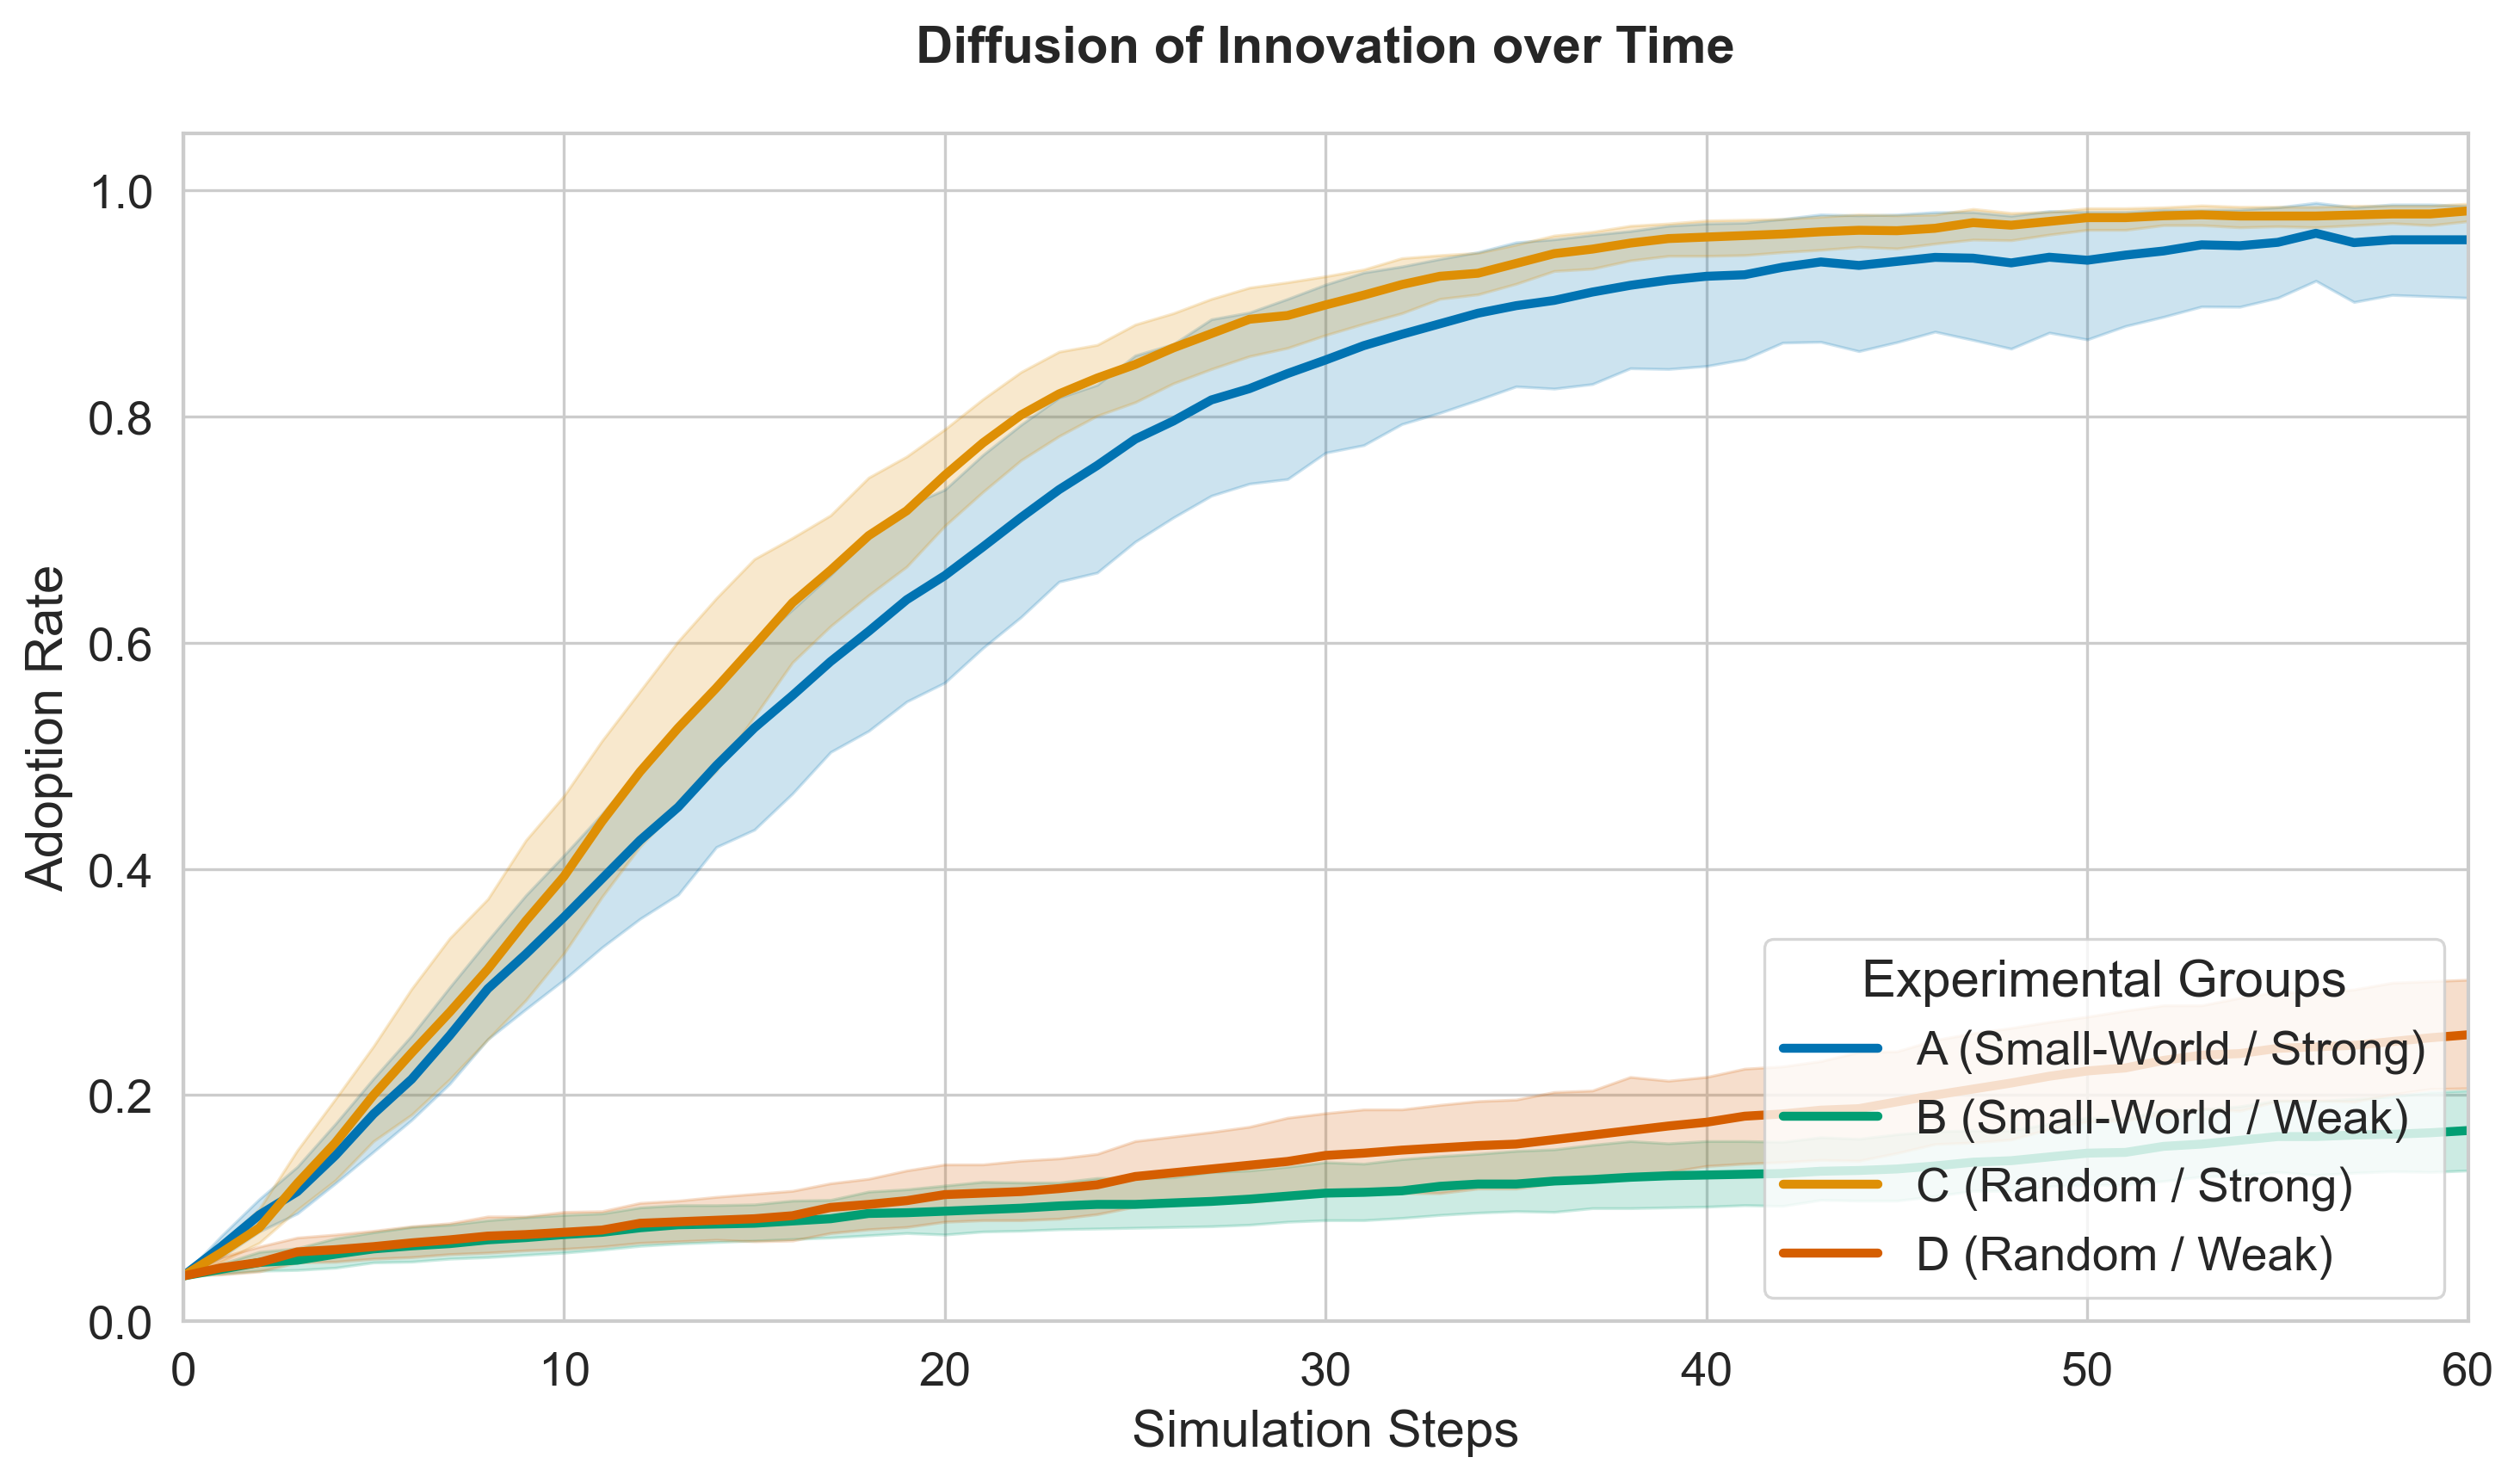

=== 最终指标箱线图 ===


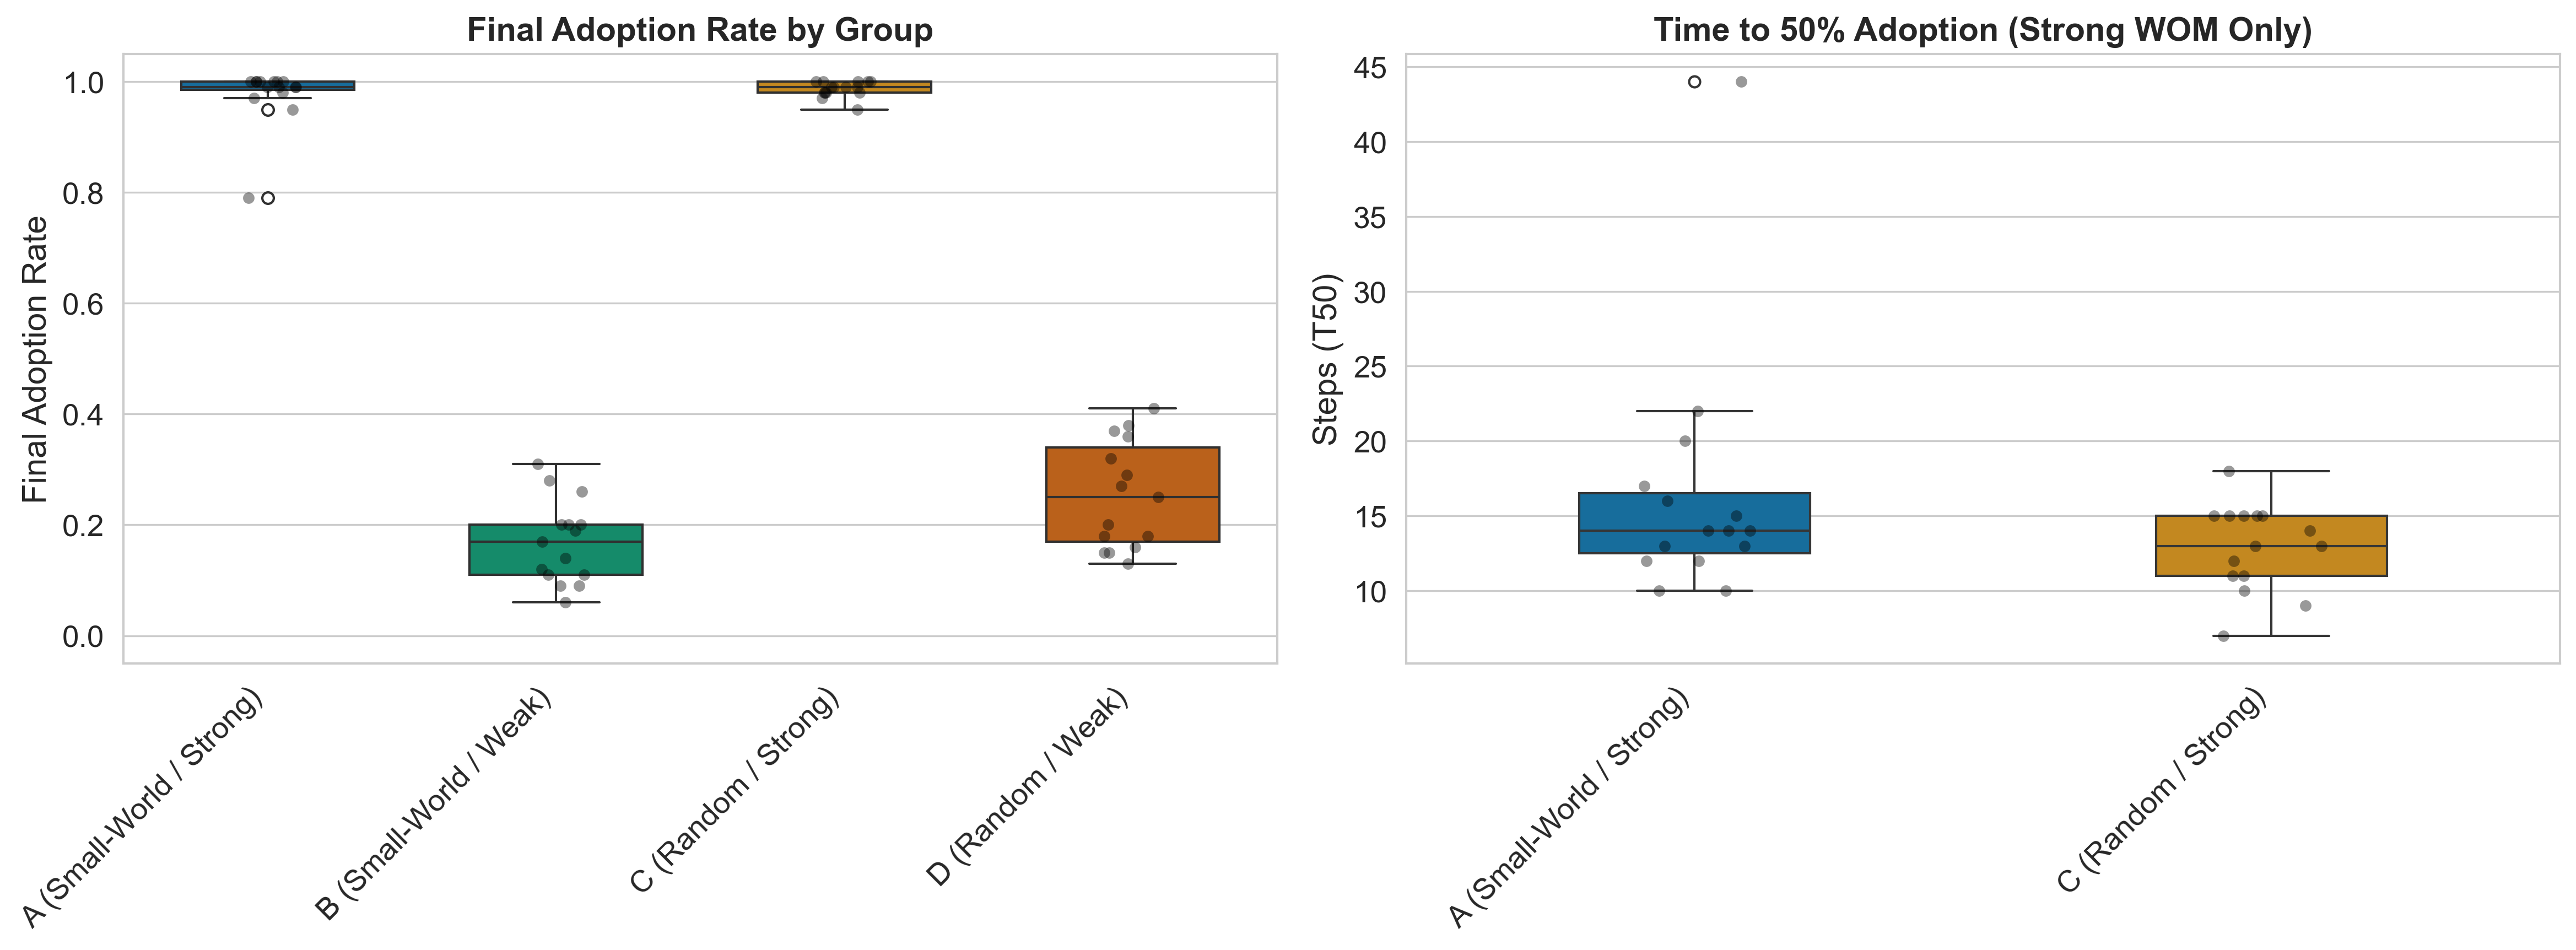

In [ ]:
!uv run python analysis/03_visualizations.py

print("=== 扩散 S 型曲线 ===")
display(Image(filename='analysis/figures/fig1_adoption_s_curves.png'))

print("=== 最终指标箱线图 ===")
display(Image(filename='analysis/figures/fig2_final_metrics_boxplots.png'))

## 5. 交互效应统计检验 (Two-way ANOVA) (`02_statistical_tests.py`)
对“网络类型”和“产品口碑强度”进行双因素方差分析，验证假设 3（交互效应）。

In [ ]:
!uv run python analysis/02_statistical_tests.py

# 如果你想在这个 notebook 里直接把玩数据，可以运行下面这段代码：
df = pd.read_csv('data/processed/analysis_dataset.csv')
model_final = ols('final_adoption_rate ~ C(network_type) + C(wom_strength) + C(network_type):C(wom_strength)', data=df).fit()
anova_final = sm.stats.anova_lm(model_final, typ=2)
print("\n【Notebook 内置的交互测试：最终采纳率的 ANOVA】")
display(anova_final)

各组均值概览:
                          final_adoption_rate           t_50       
                                         mean    std    mean    std
network_type wom_strength                                          
random       strong                     0.987  0.014  12.867  2.875
             weak                       0.253  0.097  60.000  0.000
small_world  strong                     0.977  0.054  16.400  8.322
             weak                       0.169  0.075  60.000  0.000

=== Two-way ANOVA: Final Adoption Rate ===
               Sum of Sq    df    F-value  PR(>F)
Network Type      0.0336   1.0     7.4749  0.0084
WOM Strength      8.9089   1.0  1981.5394  0.0000
Network × WOM     0.0209   1.0     4.6501  0.0354
Residual          0.2518  56.0        NaN     NaN

=> 结论: 存在显著的【交互效应】 (p < 0.05)。网络结构的作用取决于口碑强度！

=== Two-way ANOVA: Time to 50% Adoption (T50) ===
                Sum of Sq    df    F-value  PR(>F)
Network Type      46.8167   1.0     2.4156  0.1258
WOM Strength   30872.0

,sum_sq,df,F,PR(>F)
C(network_type),0.033607,1.0,7.474872,8.360096e-03
C(wom_strength),8.908907,1.0,1981.539374,2.118576e-45
C(network_type):C(wom_strength),0.020907,1.0,4.650109,3.536085e-02
Residual,0.251773,56.0,NaN,NaN


## 6. 网络拓扑与微观机制可视化 (`05` & `07`)
解释为什么在小世界网络中距离更长，以及为什么弱产品在随机网络中存活率更高。

正在绘制网络拓扑对比图...
✅ 网络拓扑图已保存: analysis/figures/fig3_network_topology_comparison.png
=== 网络拓扑对比 ===


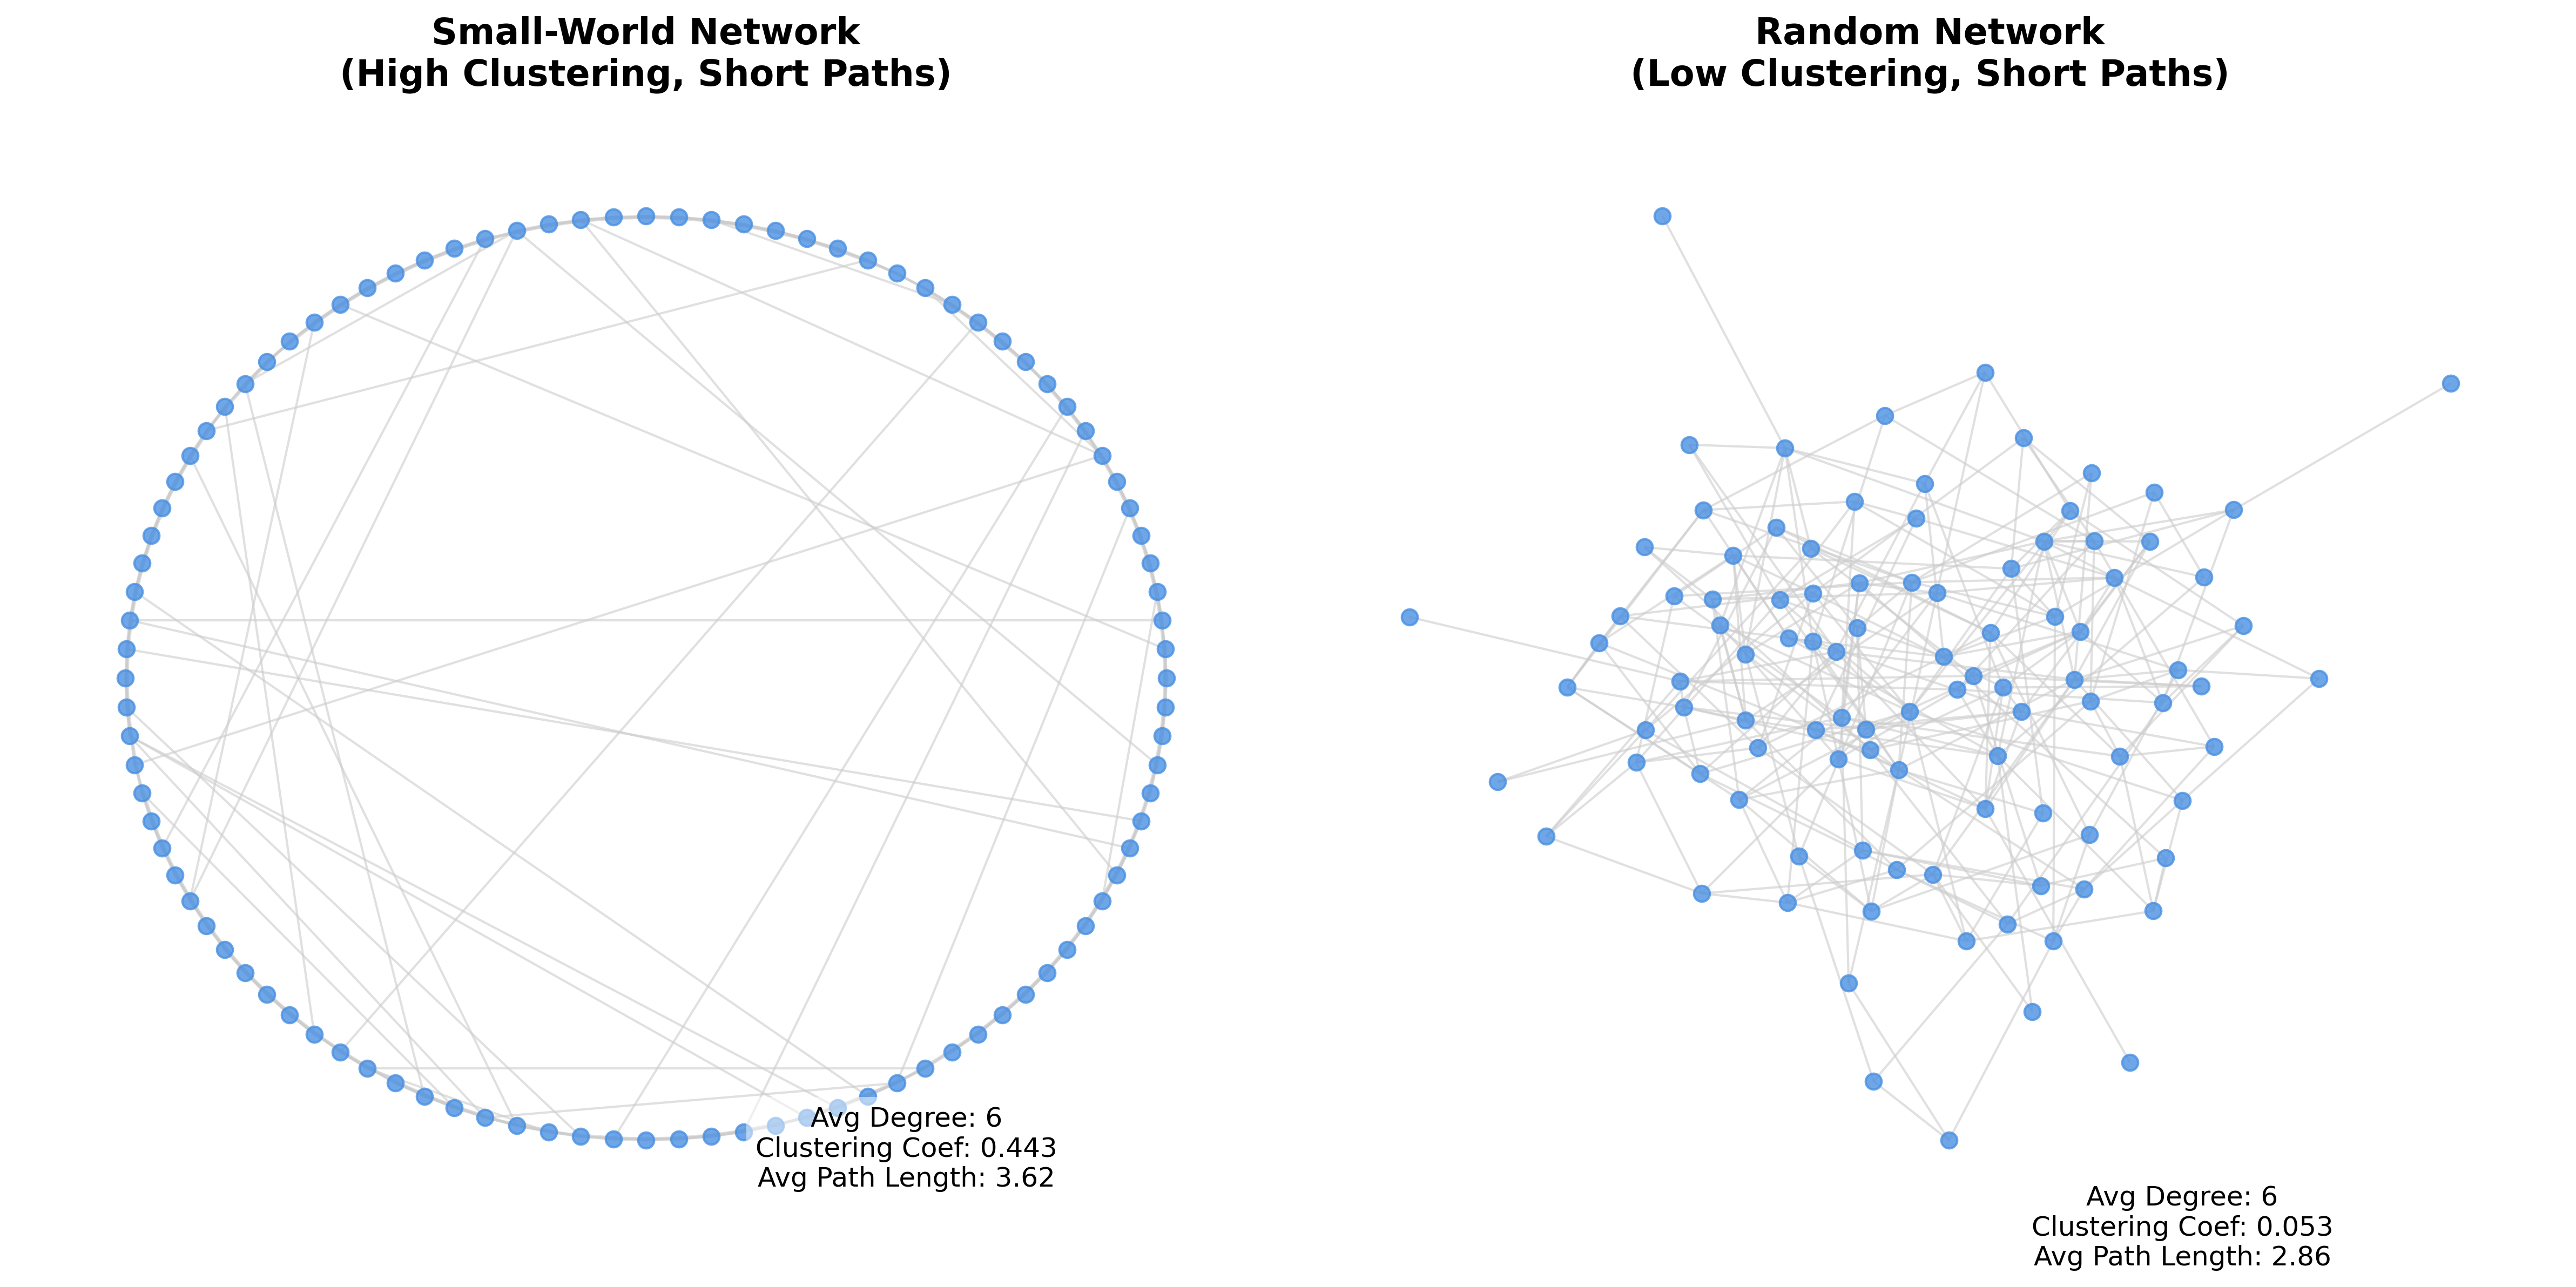

In [ ]:
!uv run python analysis/05_network_topology_vis.py
print("=== 网络拓扑对比 ===")
display(Image(filename='analysis/figures/fig3_network_topology_comparison.png'))

正在提取采纳者状态...
Group B (小世界+弱产品) 最终采纳人数: 9
Group D (随机网络+弱产品) 最终采纳人数: 25
正在重建网络拓扑...
✅ 微观机制对比图已保存: analysis/figures/fig5_micro_mechanism.png
=== 弱产品扩散的微观机制切面图 ===


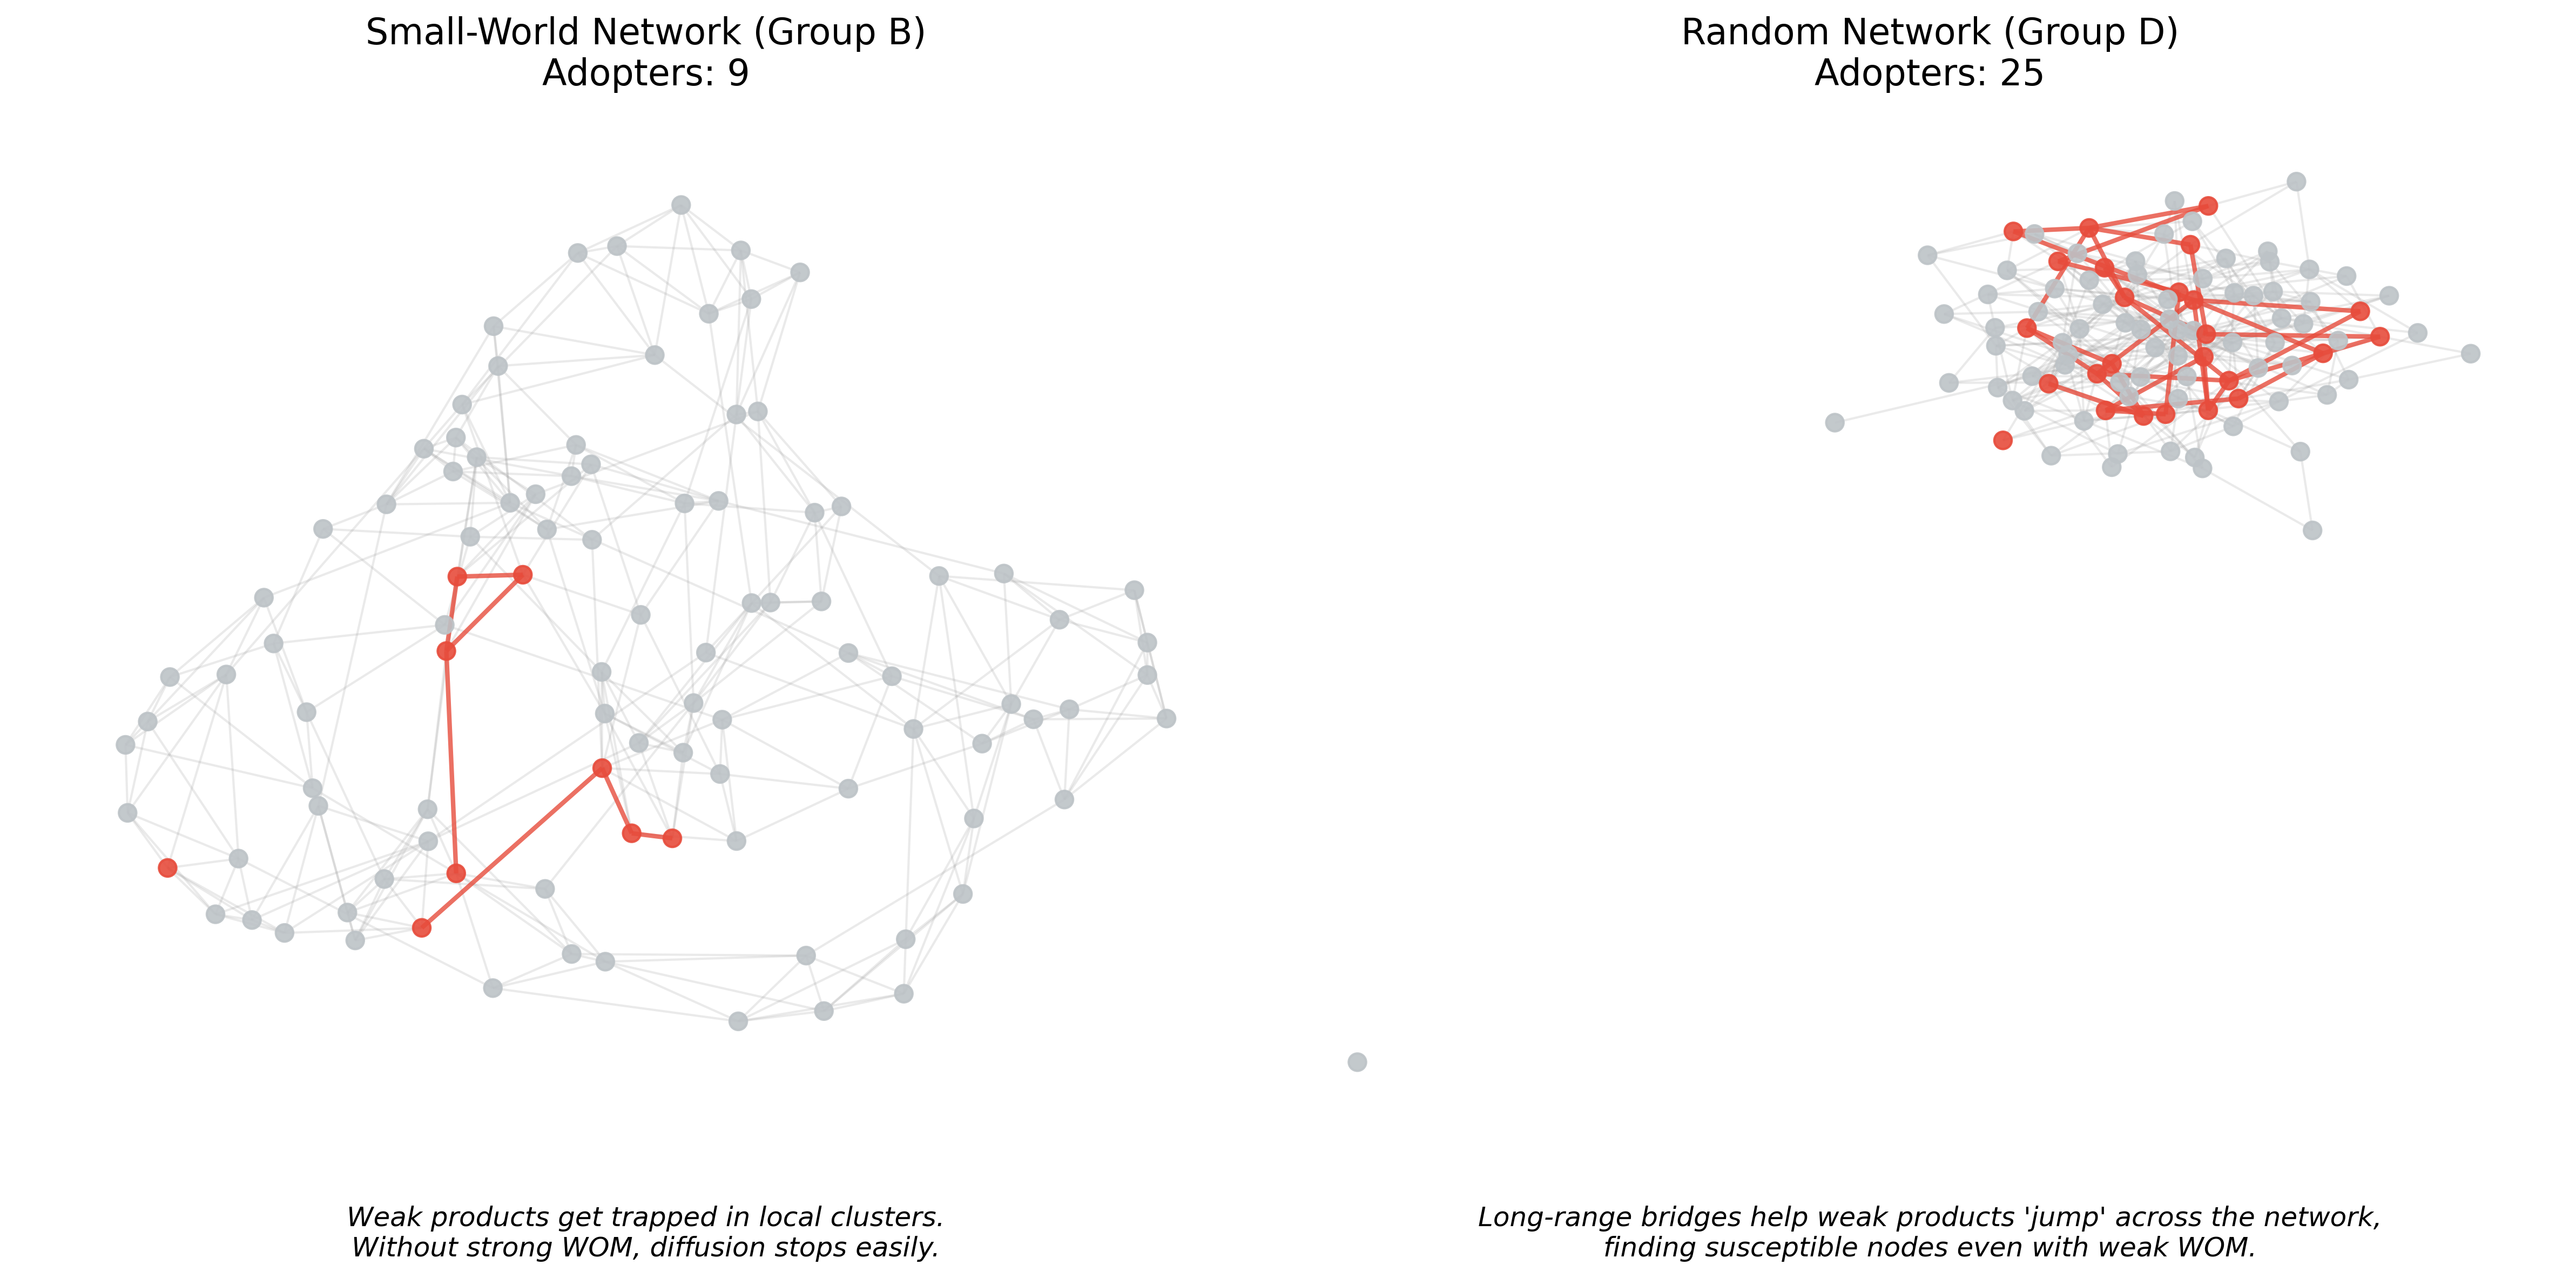

In [ ]:
!uv run python analysis/07_micro_mechanism_vis.py
print("=== 弱产品扩散的微观机制切面图 ===")
display(Image(filename='analysis/figures/fig5_micro_mechanism.png'))